# Auditor de Sesgo en CVs — Análisis Exploratorio
**Caso 2 — Sesgo en selección de CVs | Introducción a la Ingeniería 2026-I**

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='Set2')

GRAFICAS_DIR = '../data/processed/graficas'
os.makedirs(GRAFICAS_DIR, exist_ok=True)

def guardar(nombre):
    ruta = os.path.join(GRAFICAS_DIR, nombre)
    plt.savefig(ruta, bbox_inches='tight')
    print(f'Guardada: {ruta}')
    plt.show()

## 1. Carga del dataset

In [2]:
COLUMNAS = [
    'edad', 'tipo_trabajo', 'fnlwgt', 'educacion',
    'educacion_num', 'estado_civil', 'ocupacion',
    'relacion', 'raza', 'sexo', 'ganancia_capital',
    'perdida_capital', 'horas_semana', 'pais_origen', 'ingreso'
]

df = pd.read_csv('../data/raw/adult.csv',
                 names=COLUMNAS, na_values=' ?', skipinitialspace=True)
df.dropna(inplace=True)
df['ingreso'] = df['ingreso'].str.strip().map(
    {'>50K': 1, '<=50K': 0, '>50K.': 1, '<=50K.': 0})
df.dropna(subset=['ingreso'], inplace=True)
df['ingreso'] = df['ingreso'].astype(int)

print(f'Shape: {df.shape}')
print(f'\nTipos:')
print(df.dtypes)
print(f'\nValores nulos:')
print(df.isnull().sum())
df.head()

Shape: (32561, 15)

Tipos:
edad                int64
tipo_trabajo          str
fnlwgt              int64
educacion             str
educacion_num       int64
estado_civil          str
ocupacion             str
relacion              str
raza                  str
sexo                  str
ganancia_capital    int64
perdida_capital     int64
horas_semana        int64
pais_origen           str
ingreso             int64
dtype: object

Valores nulos:
edad                0
tipo_trabajo        0
fnlwgt              0
educacion           0
educacion_num       0
estado_civil        0
ocupacion           0
relacion            0
raza                0
sexo                0
ganancia_capital    0
perdida_capital     0
horas_semana        0
pais_origen         0
ingreso             0
dtype: int64


,edad,tipo_trabajo,fnlwgt,educacion,educacion_num,estado_civil,ocupacion,relacion,raza,sexo,ganancia_capital,perdida_capital,horas_semana,pais_origen,ingreso
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


## 2. Distribución de la variable objetivo

Guardada: ../data/processed/graficas/01_distribucion_objetivo.png


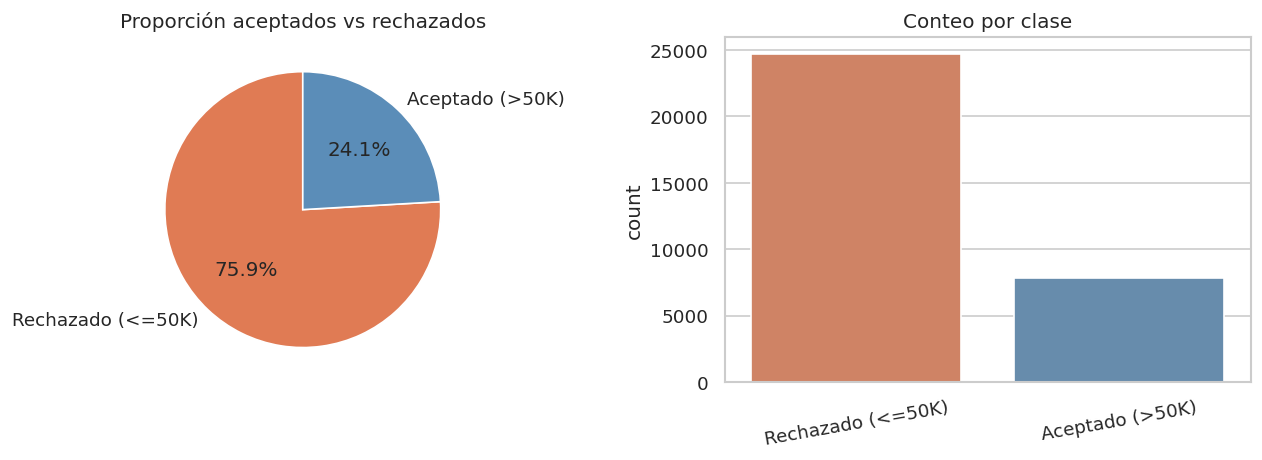

In [3]:
conteos = df['ingreso'].value_counts()
etiquetas = ['Rechazado (<=50K)', 'Aceptado (>50K)']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].pie(conteos, labels=etiquetas, autopct='%1.1f%%',
            colors=['#e07b54', '#5b8db8'], startangle=90)
axes[0].set_title('Proporción aceptados vs rechazados')

sns.countplot(x='ingreso', data=df, ax=axes[1],
              hue='ingreso', palette={0: '#e07b54', 1: '#5b8db8'}, legend=False)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(etiquetas, rotation=10)
axes[1].set_xlabel('')
axes[1].set_title('Conteo por clase')

plt.tight_layout()
guardar('01_distribucion_objetivo.png')

## 3. Sesgo por edad

Guardada: ../data/processed/graficas/02_sesgo_edad.png


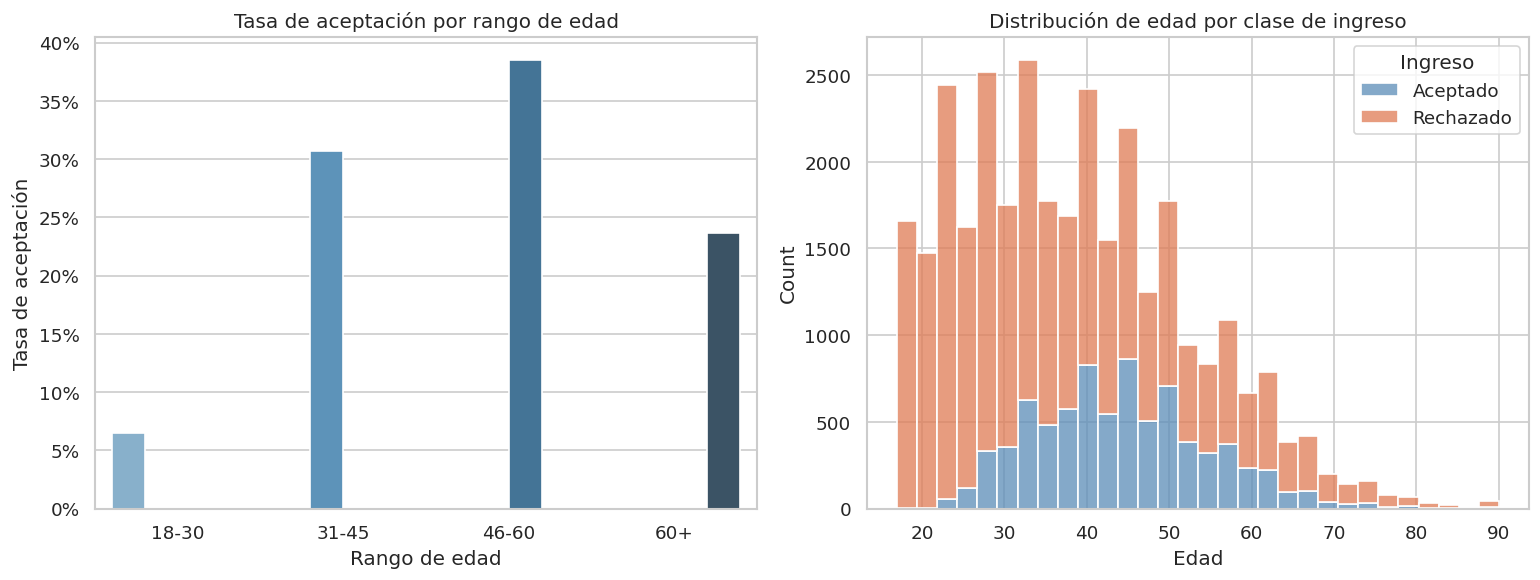

In [4]:
bins   = [0, 30, 45, 60, 120]
labels = ['18-30', '31-45', '46-60', '60+']
df['rango_edad'] = pd.cut(df['edad'], bins=bins, labels=labels)

tasa_edad = (df.groupby('rango_edad', observed=True)['ingreso']
               .mean()
               .reset_index()
               .rename(columns={'ingreso': 'tasa_aceptacion'}))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(x='rango_edad', y='tasa_aceptacion', data=tasa_edad,
            ax=axes[0], hue='rango_edad', palette='Blues_d', legend=False)
axes[0].set_title('Tasa de aceptación por rango de edad')
axes[0].set_ylabel('Tasa de aceptación')
axes[0].set_xlabel('Rango de edad')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

sns.histplot(data=df, x='edad', hue='ingreso', multiple='stack',
             bins=30, ax=axes[1], palette=['#e07b54', '#5b8db8'])
axes[1].set_title('Distribución de edad por clase de ingreso')
axes[1].set_xlabel('Edad')
axes[1].legend(title='Ingreso', labels=['Aceptado', 'Rechazado'])

plt.tight_layout()
guardar('02_sesgo_edad.png')

## 4. Sesgo por sexo

Guardada: ../data/processed/graficas/03_sesgo_sexo.png


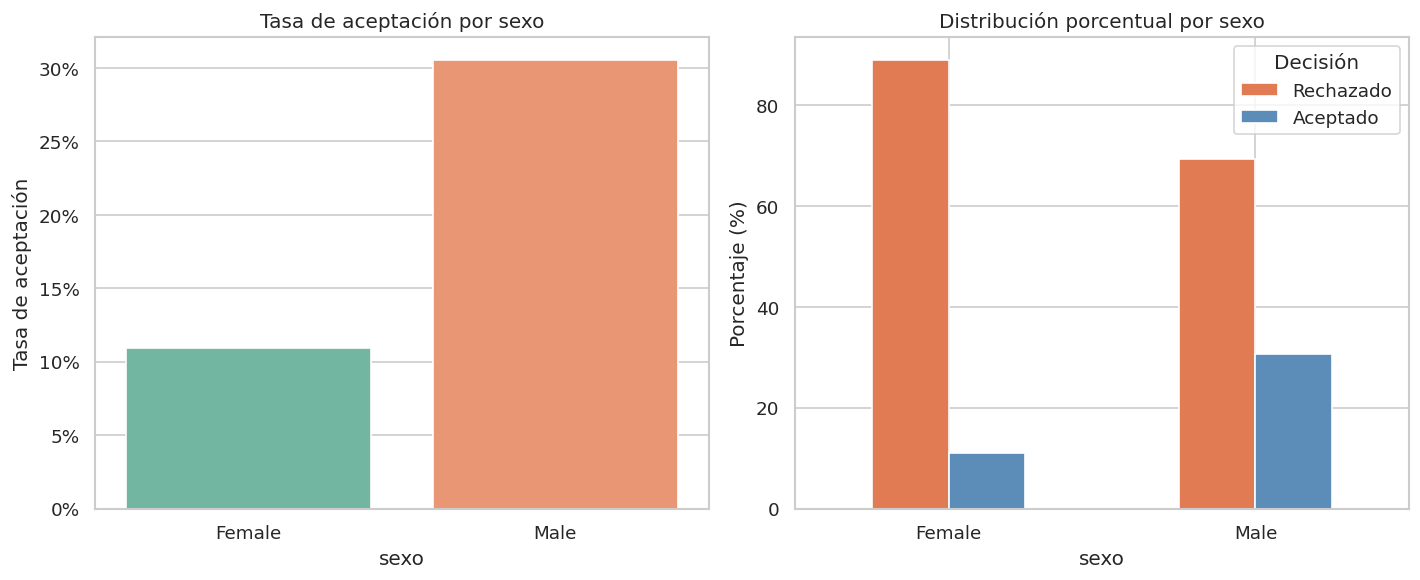

In [5]:
tasa_sexo = (df.groupby('sexo')['ingreso']
               .mean()
               .reset_index()
               .rename(columns={'ingreso': 'tasa_aceptacion'}))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x='sexo', y='tasa_aceptacion', data=tasa_sexo,
            ax=axes[0], hue='sexo', palette='Set2', legend=False)
axes[0].set_title('Tasa de aceptación por sexo')
axes[0].set_ylabel('Tasa de aceptación')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Conteo cruzado sexo × decisión
tabla = pd.crosstab(df['sexo'], df['ingreso'], normalize='index') * 100
tabla.columns = ['Rechazado', 'Aceptado']
tabla.plot(kind='bar', ax=axes[1], color=['#e07b54', '#5b8db8'],
           edgecolor='white', rot=0)
axes[1].set_title('Distribución porcentual por sexo')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].legend(title='Decisión')

plt.tight_layout()
guardar('03_sesgo_sexo.png')

## 5. Sesgo por país de origen (top 10)

Guardada: ../data/processed/graficas/04_sesgo_pais.png


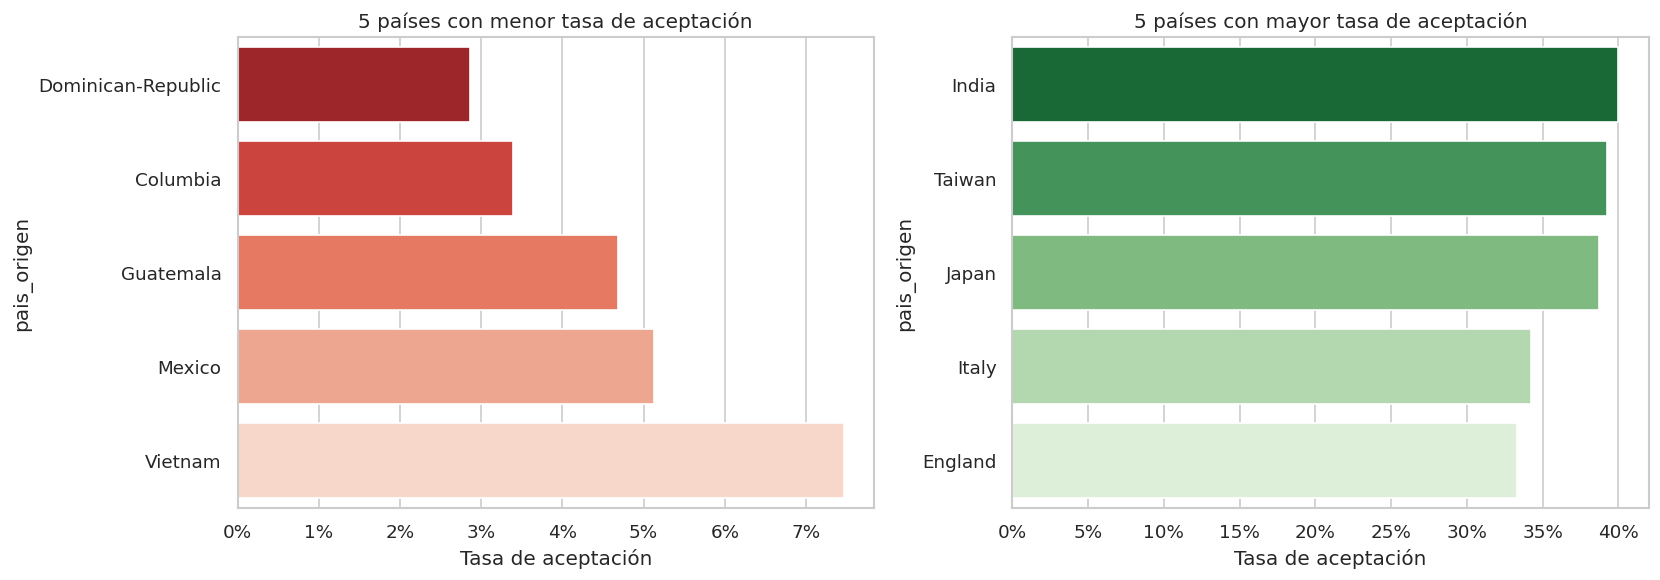

In [6]:
tasa_pais = (df.groupby('pais_origen')['ingreso']
               .agg(['mean', 'count'])
               .reset_index()
               .rename(columns={'mean': 'tasa_aceptacion', 'count': 'total'}))

# Filtrar países con ≥ 50 registros para mayor fiabilidad
tasa_pais = tasa_pais[tasa_pais['total'] >= 50].sort_values('tasa_aceptacion')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 5 países con menor tasa
bottom5 = tasa_pais.head(5)
sns.barplot(x='tasa_aceptacion', y='pais_origen', data=bottom5,
            ax=axes[0], hue='pais_origen', palette='Reds_r', legend=False)
axes[0].set_title('5 países con menor tasa de aceptación')
axes[0].set_xlabel('Tasa de aceptación')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# 5 países con mayor tasa
top5 = tasa_pais.tail(5).sort_values('tasa_aceptacion', ascending=False)
sns.barplot(x='tasa_aceptacion', y='pais_origen', data=top5,
            ax=axes[1], hue='pais_origen', palette='Greens_r', legend=False)
axes[1].set_title('5 países con mayor tasa de aceptación')
axes[1].set_xlabel('Tasa de aceptación')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
guardar('04_sesgo_pais.png')

## 6. Comparación de modelos — sesgado vs justo

In [7]:
import pickle
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

CATEGORICAS = [
    'tipo_trabajo', 'educacion', 'estado_civil',
    'ocupacion', 'relacion', 'raza', 'sexo', 'pais_origen'
]

# Codificar dataset
df_cod = df.copy()
for col in CATEGORICAS:
    df_cod[col] = LabelEncoder().fit_transform(df_cod[col].astype(str))

y = df_cod['ingreso']
idx = np.arange(len(df))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42)
y_test = y.iloc[idx_test]

# Cargar modelos
with open('../model/modelo_sesgado.pkl', 'rb') as f:
    meta_s = pickle.load(f)
with open('../model/modelo_justo.pkl', 'rb') as f:
    meta_j = pickle.load(f)

clf_s    = meta_s['modelo']; feat_s = meta_s['features']
clf_j    = meta_j['modelo']; feat_j = meta_j['features']
umbrales = meta_j['umbrales']   # umbrales calibrados por sexo

print('Umbrales calibrados modelo justo:')
for sexo, u in umbrales.items():
    print(f'  {sexo}: {u:.3f}')

X_s = df_cod[feat_s]
X_j = df_cod[feat_j]

# --- Predicciones modelo sesgado (umbral fijo 0.5) ---
pred_s_all  = clf_s.predict(X_s)
pred_s_test = clf_s.predict(X_s.iloc[idx_test])

# --- Predicciones modelo justo con umbrales calibrados por sexo ---
probas_j_all  = clf_j.predict_proba(X_j)[:, 1]
probas_j_test = clf_j.predict_proba(X_j.iloc[idx_test])[:, 1]

pred_j_all  = np.zeros(len(df), dtype=int)
pred_j_test = np.zeros(len(idx_test), dtype=int)

df_test_orig = df.iloc[idx_test].reset_index(drop=True)

for sexo, umbral in umbrales.items():
    mask_all  = (df['sexo'] == sexo).values
    mask_test = (df_test_orig['sexo'] == sexo).values
    pred_j_all[mask_all]   = (probas_j_all[mask_all]   >= umbral).astype(int)
    pred_j_test[mask_test] = (probas_j_test[mask_test] >= umbral).astype(int)

acc_s = accuracy_score(y_test, pred_s_test)
acc_j = accuracy_score(y_test, pred_j_test)
print(f'\nAccuracy modelo sesgado: {acc_s:.4f}')
print(f'Accuracy modelo justo  : {acc_j:.4f}')

Umbrales calibrados modelo justo:
  Female: 0.053
  Male: 0.727



Accuracy modelo sesgado: 0.8620
Accuracy modelo justo  : 0.7953


Guardada: ../data/processed/graficas/05_comparacion_modelos.png


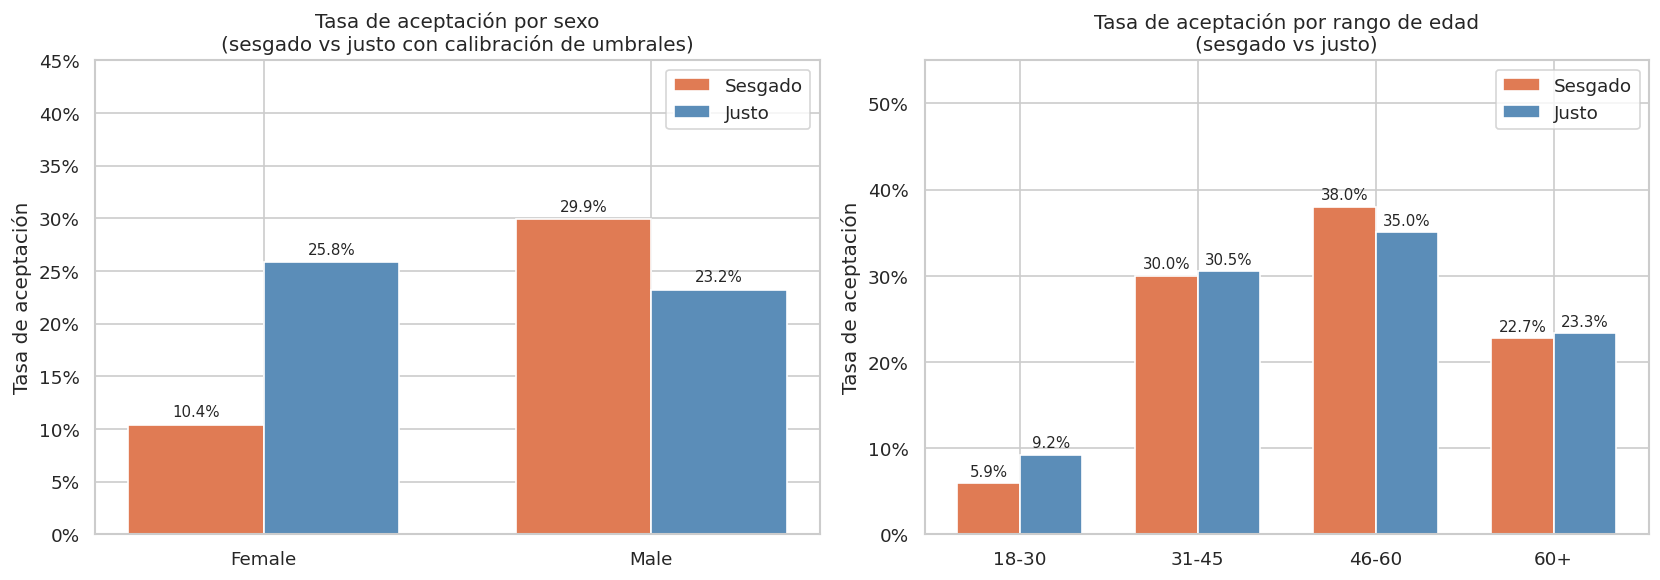

In [8]:
# Tasa de aceptación por sexo y por rango de edad — sesgado vs justo
df_comp = df.copy()
df_comp['pred_sesgado'] = pred_s_all
df_comp['pred_justo']   = pred_j_all

# ── Por sexo ──────────────────────────────────────────────────────────────────
tasa_s_sexo = df_comp.groupby('sexo')['pred_sesgado'].mean()
tasa_j_sexo = df_comp.groupby('sexo')['pred_justo'].mean()

sexos = list(tasa_s_sexo.index)
x = np.arange(len(sexos))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars_s = axes[0].bar(x - w/2, tasa_s_sexo.values, w, label='Sesgado', color='#e07b54')
bars_j = axes[0].bar(x + w/2, tasa_j_sexo.values, w, label='Justo',   color='#5b8db8')
for bar in bars_s:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=9)
for bar in bars_j:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(sexos)
axes[0].set_title('Tasa de aceptación por sexo\n(sesgado vs justo con calibración de umbrales)')
axes[0].set_ylabel('Tasa de aceptación')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[0].legend()
axes[0].set_ylim(0, 0.45)

# ── Por rango de edad ─────────────────────────────────────────────────────────
bins   = [0, 30, 45, 60, 120]
labels = ['18-30', '31-45', '46-60', '60+']
df_comp['rango_edad'] = pd.cut(df_comp['edad'], bins=bins, labels=labels)

tasa_s_edad = df_comp.groupby('rango_edad', observed=True)['pred_sesgado'].mean()
tasa_j_edad = df_comp.groupby('rango_edad', observed=True)['pred_justo'].mean()

rangos = list(tasa_s_edad.index)
x2 = np.arange(len(rangos))

bars_s2 = axes[1].bar(x2 - w/2, tasa_s_edad.values, w, label='Sesgado', color='#e07b54')
bars_j2 = axes[1].bar(x2 + w/2, tasa_j_edad.values, w, label='Justo',   color='#5b8db8')
for bar in bars_s2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=9)
for bar in bars_j2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=9)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(rangos)
axes[1].set_title('Tasa de aceptación por rango de edad\n(sesgado vs justo)')
axes[1].set_ylabel('Tasa de aceptación')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].legend()
axes[1].set_ylim(0, 0.55)

plt.tight_layout()
guardar('05_comparacion_modelos.png')

Guardada: ../data/processed/graficas/06_accuracy_y_brecha.png


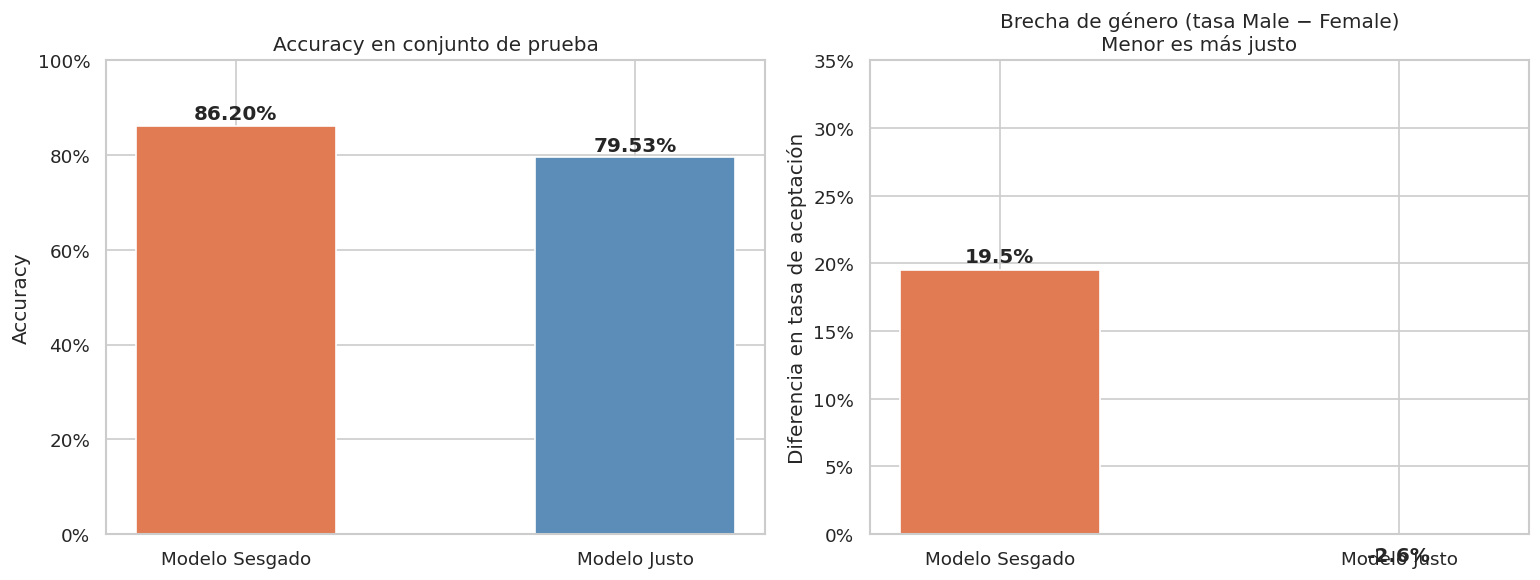


Brecha de género  — Sesgado: 19.5%  |  Justo: -2.6%
Reducción de brecha: 113%


In [9]:
# Accuracy y brecha de género por modelo
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Accuracy ---
modelos = ['Modelo Sesgado', 'Modelo Justo']
accs    = [acc_s, acc_j]
bars = axes[0].bar(modelos, accs, color=['#e07b54', '#5b8db8'], width=0.5)
for bar, val in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                 f'{val:.2%}', ha='center', va='bottom', fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].set_title('Accuracy en conjunto de prueba')
axes[0].set_ylabel('Accuracy')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# --- Brecha de género (diferencia Male - Female) ---
brecha_s = tasa_s_sexo['Male'] - tasa_s_sexo['Female']
brecha_j = tasa_j_sexo['Male'] - tasa_j_sexo['Female']

brechas = [brecha_s, brecha_j]
colores = ['#e07b54', '#5b8db8']
bars2 = axes[1].bar(modelos, brechas, color=colores, width=0.5)
for bar, val in zip(bars2, brechas):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.003,
                 f'{val:.1%}', ha='center', va='bottom', fontweight='bold')
axes[1].set_ylim(0, 0.35)
axes[1].set_title('Brecha de género (tasa Male − Female)\nMenor es más justo')
axes[1].set_ylabel('Diferencia en tasa de aceptación')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
guardar('06_accuracy_y_brecha.png')

print(f'\nBrecha de género  — Sesgado: {brecha_s:.1%}  |  Justo: {brecha_j:.1%}')
print(f'Reducción de brecha: {(brecha_s - brecha_j)/brecha_s:.0%}')

Guardada: ../data/processed/graficas/07_importancia_variables.png


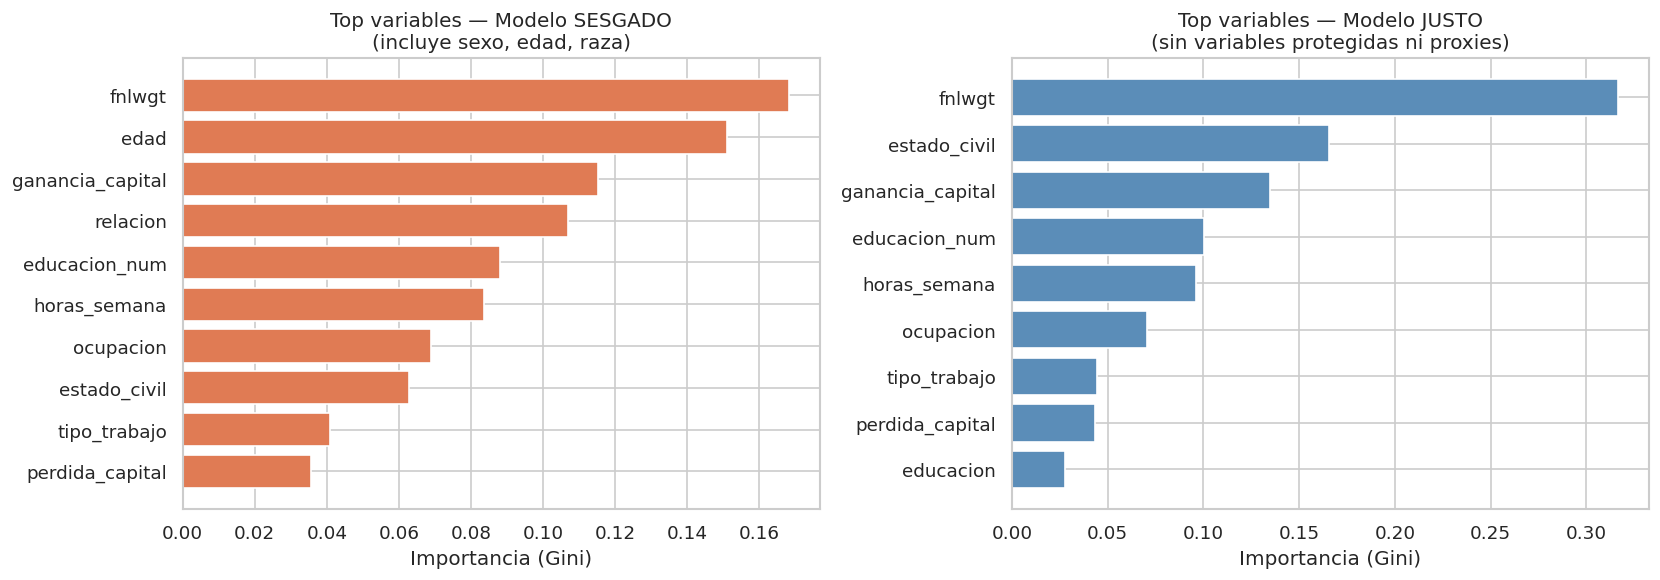

In [10]:
# Importancia de variables por modelo (feature_importances_ del RandomForest — instantáneo)
imp_s = pd.Series(clf_s.feature_importances_, index=feat_s).sort_values(ascending=True).tail(10)
imp_j = pd.Series(clf_j.feature_importances_, index=feat_j).sort_values(ascending=True).tail(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(imp_s.index, imp_s.values, color='#e07b54')
axes[0].set_title('Top variables — Modelo SESGADO\n(incluye sexo, edad, raza)')
axes[0].set_xlabel('Importancia (Gini)')

axes[1].barh(imp_j.index, imp_j.values, color='#5b8db8')
axes[1].set_title('Top variables — Modelo JUSTO\n(sin variables protegidas ni proxies)')
axes[1].set_xlabel('Importancia (Gini)')

plt.tight_layout()
guardar('07_importancia_variables.png')